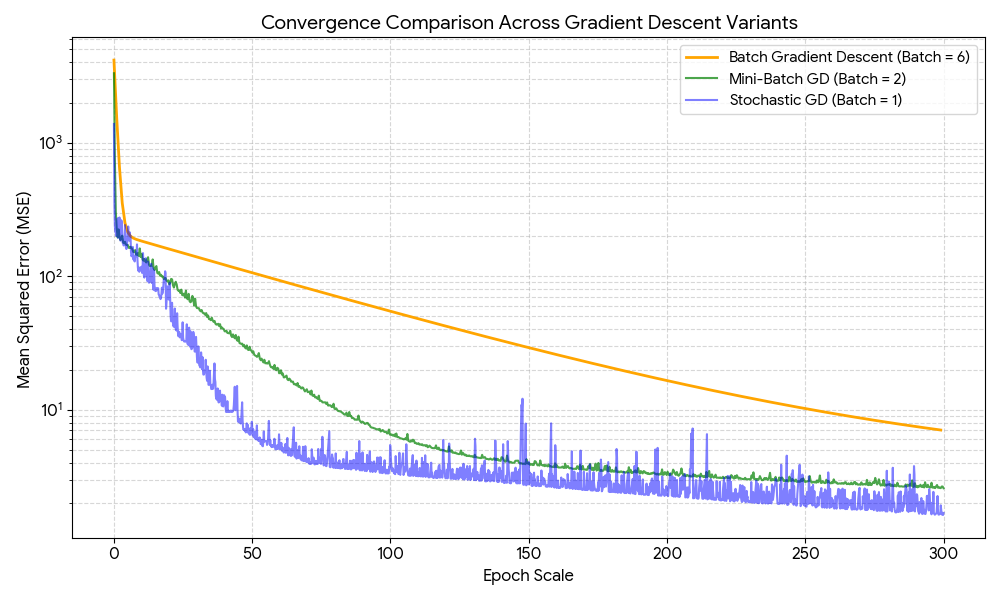

The primary difference between the three approaches lies in **how much data is processed before updating the model weights**.

| Feature / Metric | **Batch Gradient Descent** | **Stochastic GD (SGD)** | **Mini-Batch GD** |
| --- | --- | --- | --- |
| **Batch Size** | Entire Dataset ($N$) | 1 sample | Small subset ($1 \lt \text{Batch} \lt N$) |
| **Updates per Epoch** | 1 update | $N$ updates | $N / \text{Batch Size}$ updates |
| **Computational Speed** | Slow for large datasets | Fast per update | Optimized via vectorization (GPUs) |
| **Path to Minimum** | Smooth, direct, deterministic | Noisy, erratic, zig-zag | Balanced, moderately smooth |
| **Memory Requirement** | High (must load full dataset) | Very Low (1 row at a time) | Low / Configurable |
| **Escaping Local Minima** | Poor (can get stuck) | High (noise helps jump out) | Moderate |

### Comparison Visualized

### Detailed Pros, Cons & Use Cases

**1. Batch Gradient Descent**

- **Pros:** Guaranteed to converge smoothly toward the minimum on convex cost functions without erratic updates; stable error gradient calculation.
- **Cons:** Extremely slow on large datasets; requires storing the entire dataset in RAM; cannot update model parameters online as new data arrives.
- **When to Use:** Small datasets that easily fit into memory (e.g., $\lt 10,000$ rows) where exact determinism is required.

**2. Stochastic Gradient Descent (SGD)**

- **Pros:** Fast feedback and memory-efficient; frequent updates allow quick progress early on; noise in gradient helps escape local minima/saddle points in complex loss landscapes.
- **Cons:** High variance in updates causes perpetual fluctuation around the minimum rather than settling in smoothly; loses hardware parallelization (vectorization) benefits.
- **When to Use:** Streaming data / online learning where data arrives continuously, or extremely memory-constrained systems.

**3. Mini-Batch Gradient Descent (Industry Standard)**

- **Pros:** Strikes the optimal balance; leverages vectorized Matrix/Tensor multiplication on GPUs/CPUs for fast execution; smoother convergence path than single-sample SGD while maintaining faster learning speeds than Batch GD.
- **Cons:** Introduces a hyperparameter (batch size, typically 32, 64, 128, or 256) that requires tuning.
- **When to Use:** Virtually all real-world machine learning and deep learning problems (e.g., training Neural Networks, PyTorch, TensorFlow, Scikit-Learn models).

In [25]:
# Import NumPy for numerical computations and matrix operations
import numpy as np

In [26]:
# Uncomment below to install NumPy if it is not already in your environment
# !pip install numpy

In [27]:
# Define the feature matrix X with shape (6, 3)
# First column: constant 1 (bias term b0)
# Second column: years of experience (feature 1)
# Third column: number of completed projects (feature 2)
X = np.array([
    [1, 1, 0],
    [1, 2, 1],
    [1, 3, 1],
    [1, 4, 2],
    [1, 5, 3],
    [1, 6, 4]
])

# Define the target variable y (salary) with shape (6,)
# These are the actual salary values corresponding to each row in X
y = np.array([39.76, 47.100, 56.978, 68.240, 77.867, 85.022])

In [28]:
# Initialize the coefficient vector beta with zeros
# beta[0] represents the bias term (intercept), beta[1] is coefficient for years of experience, 
# and beta[2] is coefficient for completed projects
beta = np.zeros(3)  # b0, b1, b2

# Define the learning rate (step size) for gradient descent
# Smaller values lead to slower convergence but more stable updates
learning_rate = 0.01

In [29]:
# Print the dimensions of each array for verification
# X.shape should be (6, 3): 6 samples, 3 features (including bias)
print(X.shape)
# y.shape should be (6,): 6 target values
print(y.shape)
# beta.shape should be (3,): 3 coefficients to learn
print(beta.shape)
# Store the number of samples for use in gradient calculations
n = len(y)

(6, 3)
(6,)
(3,)


In [30]:
# Display the initial beta values (all zeros before training begins)
print("Initial beta:", beta)

Initial beta: [0. 0. 0.]


In [31]:
# ===== Iteration 1: Manual Gradient Descent Step =====

# Verify the shape of beta coefficients
print(beta.shape)

# Step 1: Make predictions using the current beta values
# y_pred = X @ beta.T computes the linear regression predictions
# @ is matrix multiplication; X is (6,3) and beta.T is (3,1), result is (6,)
# beta.T is the transpose of beta, but since beta is a 1D array, it behaves like a column vector in this context
# y_pred will contain the predicted salary values based on the current beta coefficients for each sample in X. 
# It will be a 1D array of shape (6,) containing the predicted salaries for each of the 6 samples.
y_pred = X @ beta.T
print("Predictions:", y_pred)

# Step 2: Calculate prediction errors (residuals)
# errors = actual values - predicted values
# Positive error means underprediction, negative means overprediction
errors = y - y_pred
print("Errors:", errors)

# Step 3: Compute the gradient of the loss function
# gradient = (X.T @ (y_pred - y)) / n
# X.T is (3,6), (y_pred - y) is (6,), so result is (3,)
# This gradient tells us which direction to move beta to reduce the error
# gradient is the average of the product of each feature and the error across all samples
# gradient is a vector of partial derivatives of the loss function with respect to each coefficient in beta
# it has 3 values. Every value s like a partial derivative w.r.t each coefficient in beta, indicating how much the loss would change if we adjusted that coefficient slightly.
gradient = (X.T @ (y_pred - y)) / n
print("Gradient:", gradient)

# Step 4: Update beta using gradient descent
# beta_new = beta_old - learning_rate * gradient
# This moves beta in the opposite direction of the gradient (downhill)
beta = beta - learning_rate * gradient

# ===== After one gradient descent update =====

# Verify the updated beta shape
print(beta.shape)
# Display the updated coefficient values
print(beta)

# Make new predictions with updated beta
y_pred = X @ beta
print("Predictions:", y_pred)

# Calculate the new errors after the update
errors = y - y_pred
print("Errors:", errors)

# Note: Matrix multiplication using @ operator
# C = np.dot(A, B) is equivalent to C = A @ B

(3,)
Predictions: [0. 0. 0. 0. 0. 0.]
Errors: [39.76  47.1   56.978 68.24  77.867 85.022]
Gradient: [ -62.4945     -246.22016667 -135.70783333]
(3,)
[0.624945   2.46220167 1.35707833]
Predictions: [ 3.08714667  6.90642667  9.36862833 13.18790833 17.00718833 20.82646833]
Errors: [36.67285333 40.19357333 47.60937167 55.05209167 60.85981167 64.19553167]


In [32]:
# ===== Loop for Iterations 2 to 999 =====
# Continue the gradient descent optimization for many iterations
for i in range(2, 1000):
    print(f"=== Iteration {i} ===")

    # Step 1: Compute predictions using current beta
    # Matrix multiplication: X (6x3) @ beta.T (3,1) = predictions (6,)
    y_pred = X @ beta.T  # Matrix multiplication: X * beta
    print("Predictions:", y_pred)

    # Step 2: Compute residual errors
    # These errors measure how far predictions are from actual values
    errors = y - y_pred
    print("Errors:", errors)

    # Step 3: Compute the gradient of the Mean Squared Error loss
    # gradient = (X.T @ (y_pred - y)) / n
    # X.T (3x6) @ (y_pred - y) (6,) = gradient (3,)
    # The gradient points in the direction of steepest increase in error
    gradient = (X.T @ (y_pred - y)) / n
    print("Gradient:", gradient)
    
    # Step 4: Update beta by moving it opposite to the gradient direction
    # beta_new = beta_old - learning_rate * gradient
    # This is the core update rule of gradient descent
    beta = beta - learning_rate * gradient

    # Display the updated coefficient values
    print("Updated beta:", beta)

    # Make predictions with the updated beta
    y_pred = X @ beta  # Matrix multiplication: X * beta
    print("Predictions:", y_pred)

# Calculate final errors after all iterations
errors = y - y_pred
print("Errors:", errors)

=== Iteration 2 ===
Predictions: [ 3.08714667  6.90642667  9.36862833 13.18790833 17.00718833 20.82646833]
Errors: [36.67285333 40.19357333 47.60937167 55.05209167 60.85981167 64.19553167]
Gradient: [ -50.76387222 -194.92812167 -106.21144833]
Updated beta: [1.13258372 4.41148288 2.41919282]
Predictions: [ 5.54406661 12.37474231 16.78622519 23.61690089 30.44757659 37.27825229]
=== Iteration 3 ===
Predictions: [ 5.54406661 12.37474231 16.78622519 23.61690089 30.44757659 37.27825229]
Errors: [34.21593339 34.72525769 40.19177481 44.62309911 47.41942341 47.74374771]
Gradient: [ -41.48653936 -154.3822955   -82.8994153 ]
Updated beta: [1.54744912 5.95530584 3.24818697]
Predictions: [ 7.50275495 16.70624776 22.6615536  31.86504641 41.06853922 50.27203202]
=== Iteration 4 ===
Predictions: [ 7.50275495 16.70624776 22.6615536  31.86504641 41.06853922 50.27203202]
Errors: [32.25724505 30.39375224 34.3164464  36.37495359 36.79846078 34.74996798]
Gradient: [ -34.14847101 -122.33100248  -64.47589335]

In [33]:
'''

=== Iteration 999 ===
Predictions: [36.864824   45.31191841 60.00010373 68.44719814 76.89429256 85.34138697]
Errors: [ 2.895176    1.78808159 -3.02210373 -0.20719814  0.97270744 -0.31938697]
Gradient: [-0.3512127   0.07942486  0.00130733]
Updated beta: [22.18015081 14.68739107 -6.24110398]
Predictions: [36.86754188 45.31382897 60.00122004 68.44750713 76.89379422 85.34008131]
Errors: [ 2.89245812  1.78617103 -3.02322004 -0.20750713  0.97320578 -0.31808131]

'''

'\n\n=== Iteration 999 ===\nPredictions: [36.864824   45.31191841 60.00010373 68.44719814 76.89429256 85.34138697]\nErrors: [ 2.895176    1.78808159 -3.02210373 -0.20719814  0.97270744 -0.31938697]\nGradient: [-0.3512127   0.07942486  0.00130733]\nUpdated beta: [22.18015081 14.68739107 -6.24110398]\nPredictions: [36.86754188 45.31382897 60.00122004 68.44750713 76.89379422 85.34008131]\nErrors: [ 2.89245812  1.78617103 -3.02322004 -0.20750713  0.97320578 -0.31808131]\n\n'

In [34]:
# Define a function to make salary predictions using the trained model
def prediction_method(years_of_exp, completed_projects):
    # Learned coefficients from the gradient descent optimization
    m0 = 22.17663868  # Intercept (bias term, multiplied by 1)
    m1 = 14.68818532  # Coefficient for years of experience
    m2 = -6.2410909   # Coefficient for completed projects
    
    # Linear regression formula: salary = m0*1 + m1*years_of_exp + m2*completed_projects
    # Calculate the predicted salary based on the input features
    salary_pred = 1*m0 + years_of_exp*m1 + completed_projects*m2
    
    # Display the predicted salary
    print("Predicted salary : ", salary_pred)

In [35]:
# Make a prediction for someone with 1 year of experience and 0 completed projects
prediction_method(1, 0)

Predicted salary :  36.864824


Final Weights (b0, b1, b2): [24.17714235 14.06230096 -5.53621241]
Final Dataset MSE: 3.4003


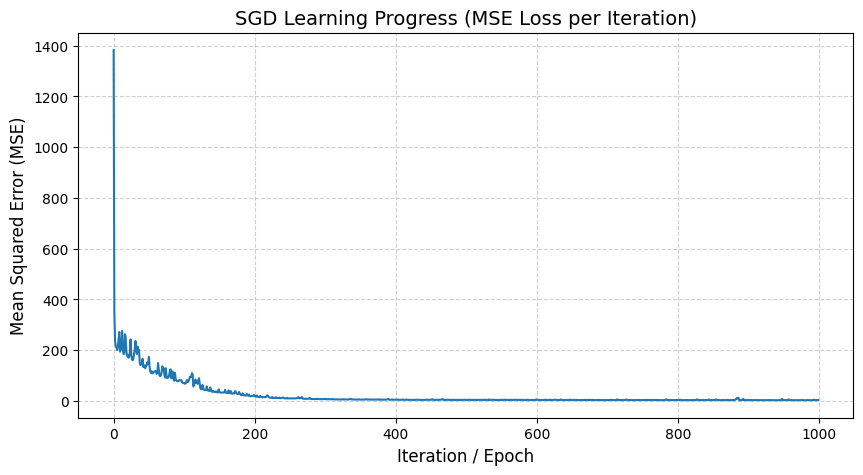

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Setup ---
X = np.array([
    [1, 1, 0],
    [1, 2, 1],
    [1, 3, 1],
    [1, 4, 2],
    [1, 5, 3],
    [1, 6, 4]
])

y = np.array([39.76, 47.100, 56.978, 68.240, 77.867, 85.022])

# --- Hyperparameters & Initialization ---
epochs = 1000
learning_rate = 0.01
np.random.seed(42)  # For reproducible random selection

n_samples, n_features = X.shape
weights = np.zeros(n_features)  # Initial weights: [0.0, 0.0, 0.0]

loss_history = []

# --- Stochastic Gradient Descent Loop ---
for epoch in range(epochs):
    # Select ONE row randomly
    random_idx = np.random.randint(0, n_samples)
    x_i = X[random_idx]
    y_i = y[random_idx]
    
    # 1. Prediction for this single row
    y_pred = np.dot(x_i, weights)
    
    # 2. Calculate error (scalar)
    error = y_pred - y_i
    
    # 3. Compute gradient for this single row: 2 * x_i * error
    gradient = 2 * x_i * error
    
    # 4. Update weights
    weights = weights - learning_rate * gradient
    
    # Track overall Mean Squared Error across the full dataset to plot learning progress
    full_dataset_mse = np.mean((np.dot(X, weights) - y) ** 2)
    loss_history.append(full_dataset_mse)

print(f"Final Weights (b0, b1, b2): {weights}")
print(f"Final Dataset MSE: {loss_history[-1]:.4f}")

# --- Plotting the Learning Curve ---
plt.figure(figsize=(10, 5))
plt.plot(range(epochs), loss_history, color='#1f77b4', linewidth=1.5)
plt.title('SGD Learning Progress (MSE Loss per Iteration)', fontsize=14)
plt.xlabel('Iteration / Epoch', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Learning Rate: 0.01
Batch Size: 2
Final Learned Weights (b0, b1, b2): [25.23954235 12.8316828  -4.2208069 ]
Final Dataset MSE: 1.8093


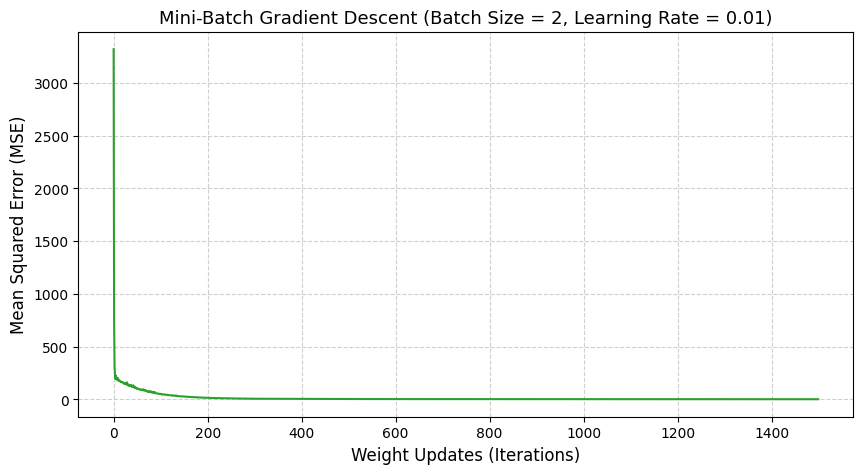

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Setup ---
X = np.array([
    [1, 1, 0],
    [1, 2, 1],
    [1, 3, 1],
    [1, 4, 2],
    [1, 5, 3],
    [1, 6, 4]
])

y = np.array([39.76, 47.100, 56.978, 68.240, 77.867, 85.022])

# --- Hyperparameters ---
epochs = 500
batch_size = 2
learning_rate = 0.01  # Specified learning rate

np.random.seed(42)  # For reproducible shuffling

n_samples, n_features = X.shape
weights = np.zeros(n_features)  # Initial weights: [0.0, 0.0, 0.0]

loss_history = []

# --- Mini-Batch Gradient Descent Loop ---
for epoch in range(epochs):
    # 1. Shuffle X and y together at the start of each epoch
    indices = np.random.permutation(n_samples)
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    
    # 2. Iterate through data in mini-batches of size 2
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]
        
        # Predictions for the current batch
        y_pred = np.dot(X_batch, weights)
        
        # Error for the batch
        error = y_pred - y_batch
        
        # Mean gradient for the batch: (2/N_batch) * X_batch^T . error
        gradient = (2 / len(X_batch)) * np.dot(X_batch.T, error)
        
        # Update weights using the learning rate
        weights = weights - learning_rate * gradient
        
        # Track overall dataset Mean Squared Error after each batch update
        full_dataset_mse = np.mean((np.dot(X, weights) - y) ** 2)
        loss_history.append(full_dataset_mse)

# --- Output Results ---
print(f"Learning Rate: {learning_rate}")
print(f"Batch Size: {batch_size}")
print(f"Final Learned Weights (b0, b1, b2): {weights}")
print(f"Final Dataset MSE: {loss_history[-1]:.4f}")

# --- Plotting the Learning Curve ---
plt.figure(figsize=(10, 5))
plt.plot(range(len(loss_history)), loss_history, color='#2ca02c', linewidth=1.5)
plt.title(f'Mini-Batch Gradient Descent (Batch Size = {batch_size}, Learning Rate = {learning_rate})', fontsize=13)
plt.xlabel('Weight Updates (Iterations)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Learning Rate: 0.01
Batch Size: 6 (Full Dataset)
Final Learned Weights (b0, b1, b2): [22.18369368 14.68805656 -6.24366573]
Final Dataset MSE: 3.6341


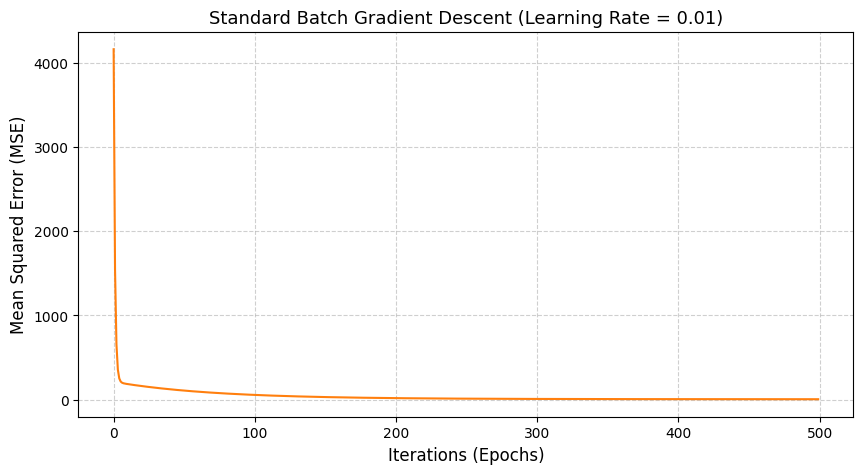

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Setup ---
X = np.array([
    [1, 1, 0],
    [1, 2, 1],
    [1, 3, 1],
    [1, 4, 2],
    [1, 5, 3],
    [1, 6, 4]
])

y = np.array([39.76, 47.100, 56.978, 68.240, 77.867, 85.022])

# --- Hyperparameters ---
epochs = 500
learning_rate = 0.01  # Specified learning rate

n_samples, n_features = X.shape
weights = np.zeros(n_features)  # Initial weights: [0.0, 0.0, 0.0]

loss_history = []

# --- Standard (Batch) Gradient Descent Loop ---
for epoch in range(epochs):
    # 1. Predictions for the ENTIRE dataset at once
    y_pred = np.dot(X, weights)
    
    # 2. Errors across all rows
    error = y_pred - y
    
    # 3. Exact gradient computed across all 6 samples: (2/N) * X^T . error
    gradient = (2 / n_samples) * np.dot(X.T, error)
    
    # 4. Update weights
    weights = weights - learning_rate * gradient
    
    # Track overall Mean Squared Error per epoch
    mse = np.mean(error ** 2)
    loss_history.append(mse)

# --- Output Results ---
print(f"Learning Rate: {learning_rate}")
print(f"Batch Size: {n_samples} (Full Dataset)")
print(f"Final Learned Weights (b0, b1, b2): {weights}")
print(f"Final Dataset MSE: {loss_history[-1]:.4f}")

# --- Plotting the Learning Curve ---
plt.figure(figsize=(10, 5))
plt.plot(range(epochs), loss_history, color='#ff7f0e', linewidth=1.5)
plt.title(f'Standard Batch Gradient Descent (Learning Rate = {learning_rate})', fontsize=13)
plt.xlabel('Iterations (Epochs)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()